In [1]:
# This code works in Python 3.10.6
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
import torch_geometric.transforms as T
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
import torch
from torch_geometric.datasets import IMDB
import os
import os.path as osp

In [3]:
def get_selected_features(X):

    col_sum = X.sum(axis=0)
    sorted_colsum = sorted(col_sum, reverse=True)
    colsum_df = pd.DataFrame(col_sum)
    
    sorted_colsum = sorted(col_sum, reverse=True)[:10]
    index_list = list(np.ravel(colsum_df[colsum_df[0].isin(sorted_colsum)].index))
    
    imp_feat = X[index_list]

    return imp_feat

## IMDB

In [4]:
dataset = IMDB(root='./imdb_data')
data = dataset[0]
data

HeteroData(
  movie={
    x=[4278, 3066],
    y=[4278],
    train_mask=[4278],
    val_mask=[4278],
    test_mask=[4278],
  },
  director={ x=[2081, 3066] },
  actor={ x=[5257, 3066] },
  (movie, to, director)={ edge_index=[2, 4278] },
  (movie, to, actor)={ edge_index=[2, 12828] },
  (director, to, movie)={ edge_index=[2, 4278] },
  (actor, to, movie)={ edge_index=[2, 12828] }
)

In [5]:
dataset = IMDB(root='./imdb_data')
data = dataset[0]
movie = data['movie'].x.tolist()
df = pd.DataFrame(movie)
df['class'] = data['movie'].y.tolist()

### Bag-of-Words features of Movie node

In [6]:
# Feature selection for Movie class 0
class0 = df[df['class'] == 0].drop(['class'], axis=1)
X = class0
imp_feat0 = get_selected_features(class0)
imp_feat0.head()

,87,102,747,1015,1023,1381,1812,1928,2095,2746
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Feature selection for Movie class 1
class1 = df[df['class'] == 1].drop(['class'], axis=1)
X = class1
imp_feat1 = get_selected_features(class1)
imp_feat1.head()

,1023,1111,1381,1624,1654,1866,1900,2393,2439,2774
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
# Feature selection for Movie class 2
class2 = df[df['class'] == 2].drop(['class'], axis=1)
X = class2
imp_feat2 = get_selected_features(class2)
imp_feat2.head()

,747,1023,1381,1624,1654,1900,1914,1928,2393,2774
21,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
42,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
52,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
def sample_features(model,node_type, n_samples):

    smpls = model.sample(n_samples)
    print("no of class {} node samples - {}".format(node_type, n_samples))
    return smpls[0]

In [10]:
def fit_sample_gm(df_class, node_type, n_samples):
    #fit
    model = GaussianMixture(n_components=1, covariance_type='full', random_state = 0)
    model.fit(df_class)
 
    #sample
    smpls = sample_features(model, node_type, n_samples)
    new_features_dict[node_type] = smpls

In [11]:
def cosine_sim(original,sampled):
    return cosine_similarity(np.array(original), np.array(sampled))

### Fit Gaussian Mixture Models to 3 Movie node classes

In [12]:
new_features_dict = {}

In [13]:
fit_sample_gm(imp_feat0, 'movie0', imp_feat0.shape[0])
fit_sample_gm(imp_feat1, 'movie1', imp_feat1.shape[0])
fit_sample_gm(imp_feat2, 'movie2', imp_feat2.shape[0])

no of class movie0 node samples - 1135
no of class movie1 node samples - 1584
no of class movie2 node samples - 1559


### Continuous features sampled using Gaussian Mixure Models

In [14]:
sampled0  = pd.DataFrame(new_features_dict['movie0'])
sampled0.head()

,0,1,2,3,4,5,6,7,8,9
0,-0.348919,0.255048,-0.182474,-0.548434,-0.063557,0.506843,-0.129721,-0.170813,0.518199,0.342026
1,-0.127060,-0.115929,-0.154157,-0.025839,-0.270651,-0.035566,-0.122532,-0.051025,0.403188,-0.141274
2,0.220737,0.399156,-0.038374,-0.025076,-0.258788,-0.458294,-0.204830,-0.641350,-0.481472,-0.401450
3,0.443159,-0.160280,0.020520,0.394096,0.110519,0.172164,-0.130385,0.105150,0.276335,-0.205497
4,-0.166133,0.245131,0.218298,-0.184146,0.702287,0.094956,0.185983,0.387264,-0.449098,-0.127166


In [15]:
sampled1  = pd.DataFrame(new_features_dict['movie1'])
sampled1.head()

,0,1,2,3,4,5,6,7,8,9
0,-0.786319,0.191685,-0.154955,-0.346224,0.067464,0.042141,-0.359523,-0.400709,-0.073847,-0.232901
1,-0.253789,-0.090783,0.442001,-0.211849,-0.287603,-0.047365,-0.212094,-0.009746,0.272220,0.242348
2,0.344432,-0.062346,0.867595,-0.608121,0.608052,-0.048954,0.340631,0.029319,-0.316358,0.674166
3,0.349060,0.180669,0.048019,-0.163769,-0.283511,0.204853,-0.111730,0.569273,0.315924,0.193897
4,0.139414,0.624410,-0.206436,0.532689,0.539644,0.357978,0.697592,-0.138412,0.127465,0.235159


In [16]:
sampled2  = pd.DataFrame(new_features_dict['movie2'])
sampled2.head()

,0,1,2,3,4,5,6,7,8,9
0,0.428584,0.694555,0.063187,0.273349,0.260372,0.749386,0.374691,0.081991,0.479900,0.210849
1,0.042942,0.249254,0.362266,0.213565,0.129342,0.023515,0.096635,0.410615,0.241898,0.321811
2,-0.171061,0.081548,0.165252,-0.050517,-0.997468,-0.603256,-0.020270,0.110994,0.667597,-0.041608
3,-0.126394,0.026019,0.012909,-0.197632,0.143267,0.087205,-0.355890,0.492363,-0.154499,0.122728
4,0.588145,-0.029708,-0.426237,-0.068112,-0.196043,-0.309234,0.190417,-0.392564,-0.330756,-0.061977


### Sampled continuous features are converted to discrete using a threshold

In [17]:
sampled_discrete_class0 = pd.DataFrame(sampled0).applymap(lambda x: 0.0 if x<0.5 else 1.0 if 0.75>=x<0.8 
                       else 2.0 if 0.8>=x<0.85 else 3.0 if 0.85>=x<0.9 
                       else 5.0 if 0.95>=x<0.99 else 0.0)
sampled_discrete_class0.head()

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [18]:
sampled_discrete_class1 = pd.DataFrame(sampled1).applymap(lambda x: 0.0 if x<0.5 else 1.0 if 0.75>=x<0.8 
                       else 2.0 if 0.8>=x<0.85 else 3.0 if 0.85>=x<0.9  else 0.0)
sampled_discrete_class1.head()

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


In [19]:
sampled_discrete_class2 = pd.DataFrame(sampled2).applymap(lambda x: 0.0 if x<0.5 else 1.0 if 0.75>=x<0.8 
                       else 2.0 if 0.8>=x<0.85 else 3.0 if 0.85>=x<0.9  else 0.0)
sampled_discrete_class2.head()

,0,1,2,3,4,5,6,7,8,9
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Pairwise cosine similarity of all features for real and synthetic distributions

Movie class 0

In [20]:
cosine_sim(imp_feat0,sampled_discrete_class0)

array([[0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       ...,
       [0.5, 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ]])

In [21]:
sns.set(font_scale=1.4)

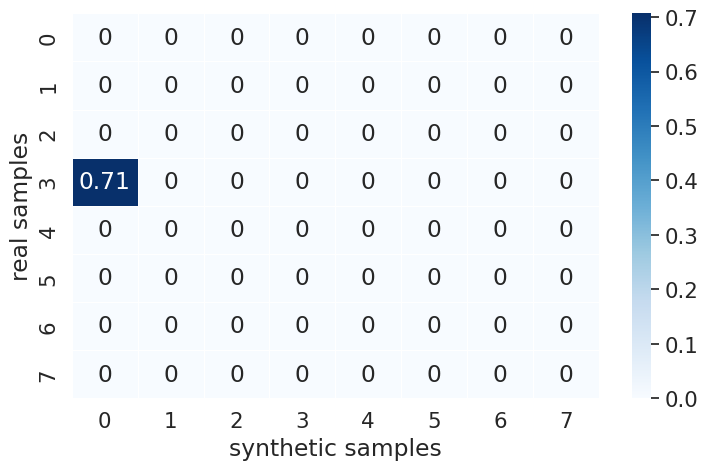

In [22]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(imp_feat0.iloc[:8],sampled_discrete_class0[:8]),xticklabels = 1, yticklabels = 1, 
            cmap='Blues', annot=True,linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [23]:
#Average cosine similarity for class 0
avg_cossim_class0 = np.mean(cosine_sim(imp_feat0,sampled_discrete_class0))
avg_cossim_class0

0.015392167275023162

Movie class 1

In [24]:
cosine_sim(imp_feat1,sampled_discrete_class1)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

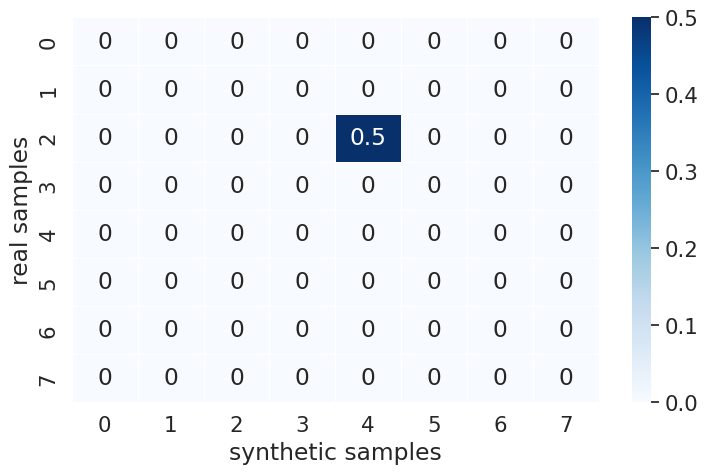

In [25]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(imp_feat1.iloc[:8],sampled_discrete_class1[:8]),xticklabels = 1, yticklabels = 1, 
            cmap='Blues', annot=True,linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [26]:
#Average cosine similarity for class 1
avg_cossim_class1 = np.mean(cosine_sim(imp_feat1,sampled_discrete_class1))
avg_cossim_class1

0.025582145617389217

Movie class 2

In [27]:
cosine_sim(imp_feat2,sampled_discrete_class2)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

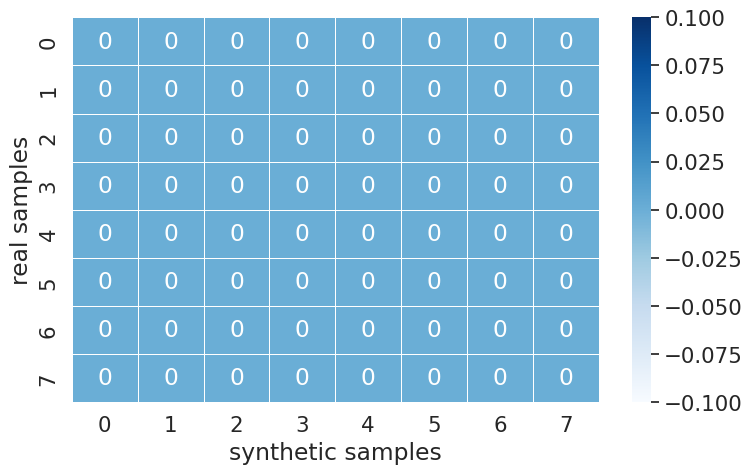

In [28]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(imp_feat2.iloc[:8],sampled_discrete_class2[:8]),xticklabels = 1, yticklabels = 1, 
            cmap='Blues', annot=True,linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [29]:
#Average cosine similarity for class 2
avg_cossim_class2 = np.mean(cosine_sim(imp_feat2,sampled_discrete_class2))
avg_cossim_class2

0.01406236891099364

Average cosine similarity for all classes

In [30]:
(avg_cossim_class0 + avg_cossim_class1 +avg_cossim_class2)/3

0.01834556060113534